In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, Model
from keras.src.legacy.preprocessing.image import ImageDataGenerator


In [2]:
def extract_patches(image, patch_size=32, stride=16):
    """Extract overlapping patches from an image"""
    patches = tf.image.extract_patches(
        images=tf.expand_dims(image, 0), # artificially increase the dimensions to (1, w, h, c), necessary for extract function
        sizes=[1, patch_size, patch_size, 1],
        strides=[1, stride, stride, 1],
        rates=[1, 1, 1, 1], # rates is used for dilatation 
        padding='VALID' # Only use fully contained patches
    )
    return tf.reshape(patches, [-1, patch_size, patch_size, image.shape[-1]]) # reshape patches to (num_patches, w, h, c)

# Example usage:
# n = 224
# images = np.array([[[x * n + y + 1] for y in range(n)] for x in range(n)]) 
# print(extract_patches(images).shape) # outputs 169,32,32,1

In [3]:
class PatchBagGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_arrays, labels, patch_size=32, stride=16, batch_size=32):
        """
        Args:
            image_arrays: Array of preloaded images (h,w,c)
            labels: Corresponding labels
            patch_size: Size of square patches
            stride: Step between patches
            batch_size: Number of images per batch
        """
        self.image_arrays = image_arrays
        self.labels = labels
        self.patch_size = patch_size
        self.stride = stride
        self.batch_size = batch_size
        self.num_samples = len(image_arrays)
        self.indices = np.arange(self.num_samples)
        assert self.image_arrays.shape == (self.num_samples, 224, 224, 1), "Image arrays shape mismatch: {} vs {}".format(image_arrays.shape, (self.num_samples, 224, 224, 1))
                
    def __len__(self):
        return int(np.ceil(self.num_samples / self.batch_size))
    
    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size] # retrieve indices for current batch index
        batch_images = [self.image_arrays[i] for i in batch_indices] # retrieve images for current batch
        batch_labels = [self.labels[i] for i in batch_indices] # retrieve labels for current batch
        
        # Process each image into patches
        batch_bags = []
        for img in batch_images:
            batch_bags.append(extract_patches(img, patch_size=self.patch_size, stride=self.stride)) 
                
        return np.array(batch_bags), np.array(batch_labels)
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices) # randomize batches for next epoch

In [42]:
def custom_augmented_generator(datagen, x, y, batch_size):
    gen = datagen.flow(x, y, batch_size=batch_size)
    for x_batch, y_batch in gen:
        x_batch_aug = []
        for img in x_batch:
            # Random horizontal flip with 50% chance
            img = tf.image.random_flip_left_right(img)

            # Random brightness adjustment
            img = tf.image.random_brightness(img, max_delta=0.05)

            # Random contrast adjustment
            img = tf.image.random_contrast(img, lower=0.95, upper=1.05)

            # Add Gaussian noise
            noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=10)
            img = img + noise
            
            x_batch_aug.append(img)
               
        x_batch_aug = tf.stack(x_batch_aug)
        yield x_batch_aug.numpy(), y_batch

In [43]:
def extract_generator_data(generator):
    """Convert generator output to arrays"""
    images, labels = [], []
    generator.reset() # ensure to retrieve all data from generator start
    for i in range(len(generator)):
        batch_img, batch_lbl = generator[i]
        images.append(batch_img)
        labels.append(batch_lbl)
    return np.vstack(images), np.vstack(labels)

def extract_from_python_generator(generator, steps):
    images, labels = [], []
    for _ in range(steps):
        batch_img, batch_lbl = next(generator)
        images.append(batch_img)
        labels.append(batch_lbl)
    return np.vstack(images), np.vstack(labels)

# initialize generator for data retrieval
train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_path = "../data/preprocessed/training"

# create training and validation generators from data
train_dir_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    color_mode="grayscale"
)

val_dir_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    color_mode="grayscale"
)

# convert generators to Data array containing images and label vector containing classes
X_train, y_train = extract_generator_data(train_dir_gen)
X_val, y_val = extract_generator_data(val_dir_gen)

# Augmenting train data
train_gen_aug = custom_augmented_generator(train_datagen, X_train, y_train, batch_size=32)

# Control number of augmented images with variable steps
total_samples = len(X_train)
augmented_samples = int(total_samples * 0.3)
batch_size = 32
steps_aug = int(np.ceil(augmented_samples / batch_size))

# convert augmentation generator to Data array
steps = int(np.ceil(len(X_train) / 32))
X_aug, y_aug = extract_from_python_generator(train_gen_aug, steps_aug)


print("Size before augmentation: " + str(X_train.shape))
X_train = np.concatenate([X_train, X_aug], axis=0)
y_train = np.concatenate([y_train, y_aug], axis=0)

# Shuffle combined dataset
idx = np.arange(len(X_train))
np.random.shuffle(idx)
X_train = X_train[idx]
y_train = y_train[idx]

print("Size after augmentation: " + str(X_train.shape))


print("Class indices:", train_dir_gen.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Size before augmentation: (2297, 224, 224, 1)
Size after augmentation: (3001, 224, 224, 1)
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


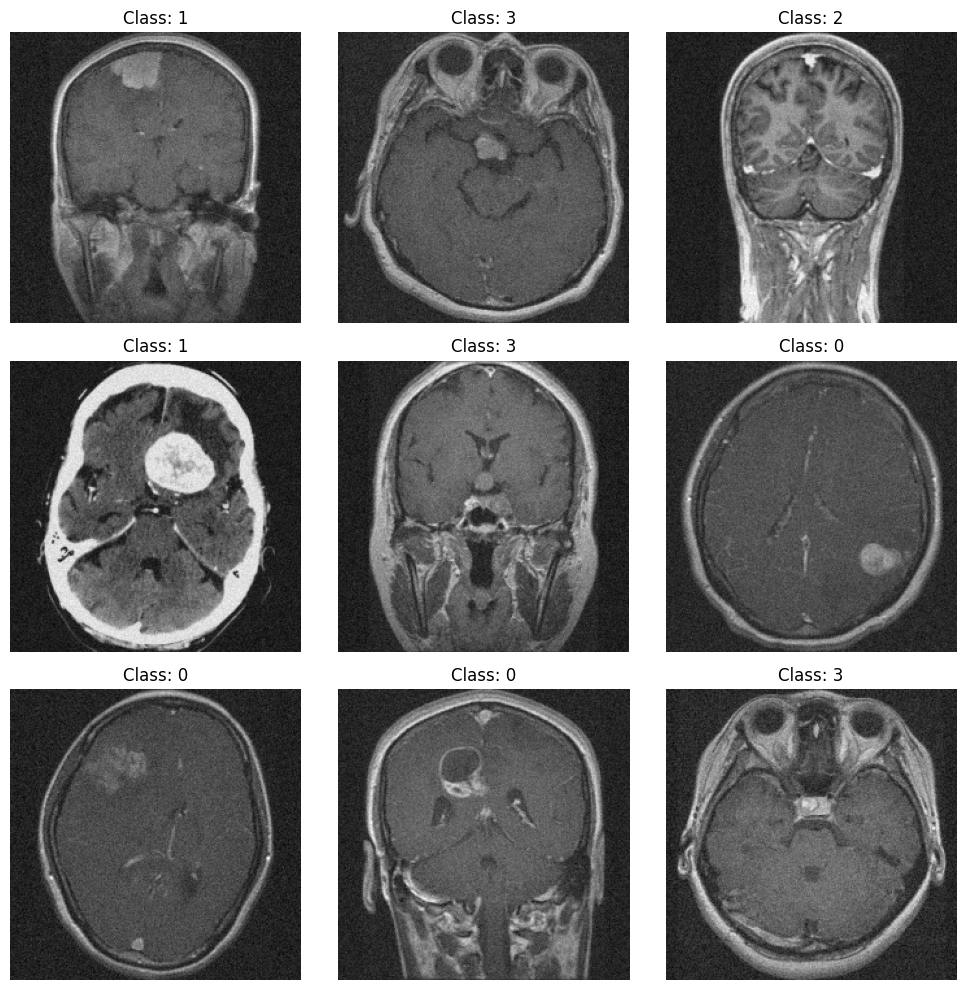

In [44]:
# Show 9 augmented images
num_images_to_show = 9
plt.figure(figsize=(10, 10))

for i in range(num_images_to_show):
    plt.subplot(3, 3, i + 1)
    img = X_aug[i].squeeze()
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"Class: {np.argmax(y_aug[i])}")

plt.tight_layout()
plt.show()

In [47]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import regularizers

def create_basic_mil_model(patch_size=32, num_classes=4):
    """Create MIL model using max/mean pooling"""
    
    # Instance-level model (processes individual patches)
    instance_input = layers.Input(shape=(patch_size, patch_size, 1))
    x = layers.Concatenate(axis=-1)([instance_input, instance_input, instance_input])
    
    # Feature extractor
    vgg = VGG16(weights='imagenet', include_top=False, input_shape=(patch_size, patch_size, 3), pooling='avg')
    vgg.trainable = False
    
    
    x = vgg(x)
    instance_output = layers.Dense(128, activation='relu')(x)
    
    instance_model = Model(instance_input, instance_output)
    
    
    # Bag-level model applying the instance level model to each of the patches (using TimeDistributed)
    bag_input = layers.Input(shape=(None, patch_size, patch_size, 1))
    x = layers.TimeDistributed(instance_model)(bag_input)
  
    x = layers.GlobalMaxPooling1D()(x)
    bag_representation = layers.Dropout(0.5)(x)
    
    # Classification head
    output = layers.Dense(num_classes, activation='softmax')(bag_representation)
    
    return Model(bag_input, output)

In [48]:
# Create and compile model
model = create_basic_mil_model(patch_size=32, num_classes=4)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Create data generators 
train_mil_gen = PatchBagGenerator(
    image_arrays=X_train,
    labels=y_train,
    patch_size=32,
    stride=32,
    batch_size=32
)


val_mil_gen = PatchBagGenerator(
    image_arrays=X_val,
    labels=y_val,
    patch_size=32,
    stride=32,
    batch_size=32
)

# Train
history = model.fit(
    train_mil_gen,
    validation_data=val_mil_gen,
    epochs=10
)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 89s 730ms/step - accuracy: 0.3316 - loss: 36.4715 - val_accuracy: 0.6649 - val_loss: 3.9332
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 341ms/step - accuracy: 0.6178 - loss: 5.7711 - val_accuracy: 0.6841 - val_loss: 2.1888
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 337ms/step - accuracy: 0.6888 - loss: 2.4143 - val_accuracy: 0.6667 - val_loss: 1.7982
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 329ms/step - accuracy: 0.7537 - loss: 1.3283 - val_accuracy: 0.6649 - val_loss: 1.5333
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 334ms/step - accuracy: 0.7524 - loss: 1.1551 - val_accuracy: 0.6963 - val_loss: 1.3532
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 325ms/step - accuracy: 0.7838 - loss: 0.9034 - val_accuracy: 0.7155 - val_loss: 1.2947
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 30s 323ms/step - accuracy: 0.8158 - loss: 0.7470 - val_accuracy: 0.6981 - val_loss: 1.3332
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 335ms/step - accuracy: 0.8248 - loss: 0.6842 - val_acc

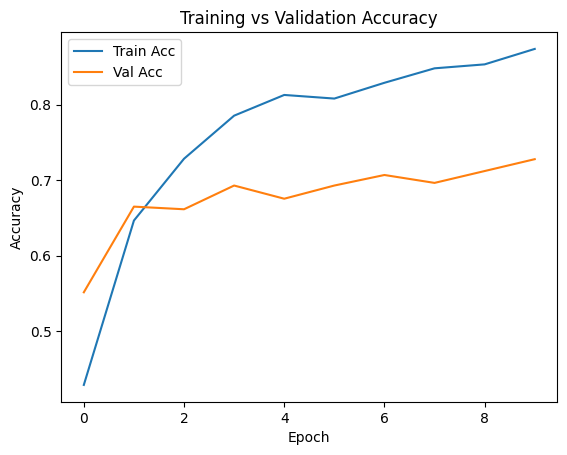

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [84]:
img_path = "../data/preprocessed/testing/meningioma_tumor/image.jpg"
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))

# Convert to NumPy array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# Normalize pixel values (optional but recommended)
img_array = img_array / 255.0

# Add batch dimension
image_rgb = tf.expand_dims(img_array, axis=0)  # shape: (1, 224, 224, 3)
print("image_rgb shape:", image_rgb.shape)

image_gray = tf.image.rgb_to_grayscale(image_rgb)

patch_size = 32
patches = tf.image.extract_patches(
        images=image_rgb, # artificially increase the dimensions to (1, w, h, c), necessary for extract function
        sizes=[1, 32, 32, 1],
        strides=[1, 16, 16, 1],
        rates=[1, 1, 1, 1], # rates is used for dilatation 
        padding='VALID' # Only use fully contained patches
    )


# Reshape to (num_patches, 32, 32, 1)
patches = tf.reshape(patches, (-1, patch_size, patch_size, 1))

# Add batch dimension: shape becomes (1, num_patches, 32, 32, 1)
input_bag = tf.expand_dims(patches, axis=0)

image_rgb shape: (1, 224, 224, 3)


In [85]:
model.predict(input_bag)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.5031118 , 0.2589801 , 0.14479758, 0.09311051]], dtype=float32)